In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test/test/test/images/test_post_00863.png
/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test/test/test/images/test_pre_00880.png
/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test/test/test/images/test_post_00364.png
/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test/test/test/images/test_post_00643.png
/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test/test/test/images/test_pre_00336.png
/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test/test/test/images/test_post_00766.png
/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test/test/test/images/test_post_00711.png
/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test/test/test/images/test_post_00012.png
/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test/test/test/images/test_pre_00458.png
/kaggle/input/datasets/tunguz/xview2-cha

In [2]:
from torch.utils.data import Dataset, DataLoader

In [3]:
import os

base_path = "/kaggle/input"

for root, dirs, files in os.walk(base_path):
    print("Folder:", root)
    print("Subfolders:", dirs)
    print("Files:", files[:3])
    print("-"*50)
    break

Folder: /kaggle/input
Subfolders: ['datasets']
Files: []
--------------------------------------------------


In [4]:
dataset_path = "/kaggle/input"

for root, dirs, files in os.walk(dataset_path):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/tunguz
/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test
/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test/test
/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test/test/test
/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test/test/test/images
/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test/train
/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test/train/train
/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test/train/train/labels
/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test/train/train/images


In [5]:
import os
import json
import cv2
import torch
from torch.utils.data import Dataset, DataLoader

In [6]:
class XBDDataset(Dataset):
    def __init__(self, image_dir, label_dir):
        self.image_dir = image_dir
        self.label_dir = label_dir
        
        self.images = [f for f in os.listdir(image_dir) if f.endswith('.png')]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        
        img_path = os.path.join(self.image_dir, img_name)
        label_path = os.path.join(self.label_dir, img_name.replace('.png', '.json'))

        # Load image
        image = cv2.imread(img_path)
        image = cv2.resize(image, (224, 224))
        image = image / 255.0
        image = torch.tensor(image, dtype=torch.float32).permute(2,0,1)

        # Load label
        with open(label_path) as f:
            data = json.load(f)

        # Default label
        damage = "no-damage"

        if "features" in data:
            for obj in data["features"]["xy"]:
                damage = obj["properties"].get("subtype", "no-damage")

        label_map = {
            "no-damage": 0,
            "minor-damage": 1,
            "major-damage": 2,
            "destroyed": 3
        }

        label = torch.tensor(label_map.get(damage, 0))

        return image, label

In [7]:
train_img_path = "/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test/train/train/images"
train_label_path = "/kaggle/input/datasets/tunguz/xview2-challenge-dataset-train-and-test/train/train/labels"

In [8]:
train_dataset = XBDDataset(train_img_path, train_label_path)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

In [9]:
for images, labels in train_loader:
    print("Image shape:", images.shape)
    print("Labels:", labels)
    break

Image shape: torch.Size([8, 3, 224, 224])
Labels: tensor([1, 0, 2, 0, 0, 0, 0, 0])


In [10]:
unique_labels = set()

for _, labels in train_loader:
    unique_labels.update(labels.tolist())
    if len(unique_labels) == 4:
        break

print("Unique labels found:", unique_labels)

Unique labels found: {0, 1, 2, 3}


In [11]:
import torch
print("GPU Available:", torch.cuda.is_available())

GPU Available: True


In [12]:
import torch.nn as nn
from torchvision import models

model = models.resnet50(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 4)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Using device:", device)

Using device: cuda


In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [15]:
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

In [16]:
epochs = 3  # keep small for now

for epoch in range(epochs):
    total_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Forward
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

KeyboardInterrupt: 

In [18]:
from torch.utils.data import Subset

small_dataset = Subset(train_dataset, range(200))
train_loader = DataLoader(small_dataset, batch_size=4, shuffle=True)

In [19]:
from torchvision import models

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 4)

epochs = 1

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [20]:
train_loader = DataLoader(small_dataset, batch_size=4, shuffle=True)

In [21]:
from torchvision import models
import torch.nn as nn

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 4)
model = model.to(device)

In [22]:
epochs = 1

for epoch in range(epochs):
    total_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 67.5410


In [23]:
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [24]:
import cv2
import torch
import matplotlib.pyplot as plt

# Example image path (change if needed)
img_path = train_img_path + "/" + train_dataset.images[0]

img = cv2.imread(img_path)
img_resized = cv2.resize(img, (224, 224))
img_norm = img_resized / 255.0

img_tensor = torch.tensor(img_norm, dtype=torch.float32).permute(2,0,1).unsqueeze(0)
img_tensor = img_tensor.to(device)

In [25]:
with torch.no_grad():
    output = model(img_tensor)
    pred = torch.argmax(output, dim=1).item()

In [26]:
classes = ["No Damage", "Minor Damage", "Major Damage", "Destroyed"]

prediction = classes[pred]
print("Prediction:", prediction)

Prediction: No Damage


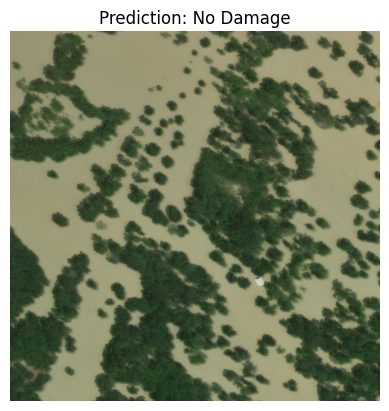

In [27]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"Prediction: {prediction}")
plt.axis("off")
plt.show()

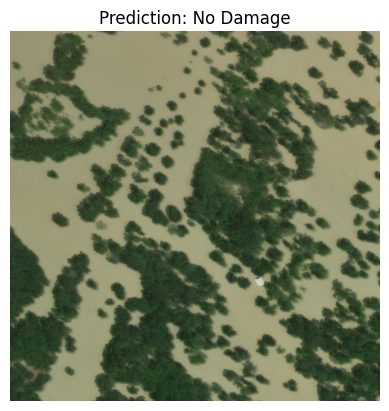

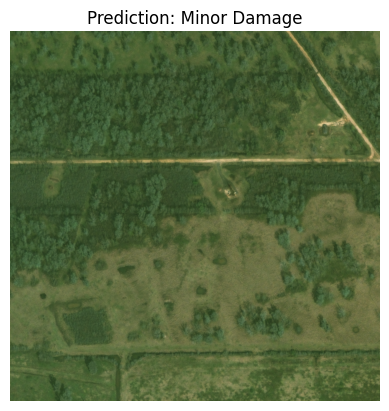

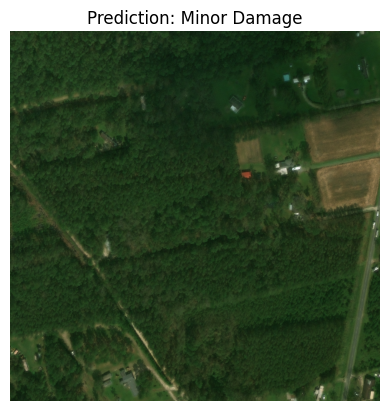

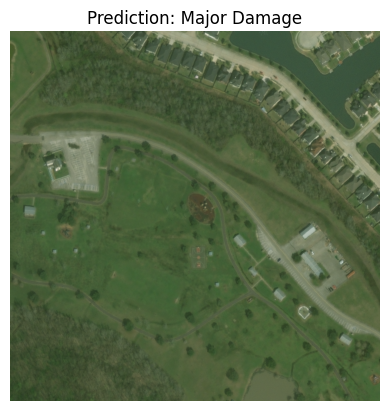

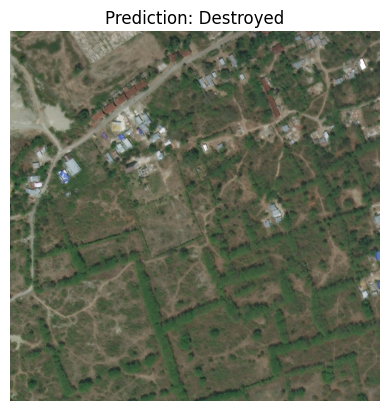

In [28]:
import matplotlib.pyplot as plt
import cv2
import torch

classes = ["No Damage", "Minor Damage", "Major Damage", "Destroyed"]

model.eval()

for i in range(5):  # change number as you want
    img_path = train_img_path + "/" + train_dataset.images[i]

    img = cv2.imread(img_path)
    img_resized = cv2.resize(img, (224, 224))
    img_norm = img_resized / 255.0

    img_tensor = torch.tensor(img_norm, dtype=torch.float32).permute(2,0,1).unsqueeze(0)
    img_tensor = img_tensor.to(device)

    with torch.no_grad():
        output = model(img_tensor)
        pred = torch.argmax(output, dim=1).item()

    prediction = classes[pred]

    # Show image
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Prediction: {prediction}")
    plt.axis("off")
    plt.show()

In [29]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [30]:
y_true = []
y_pred = []

model.eval()

with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

In [32]:
accuracy = accuracy_score(y_true, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.23


In [33]:
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[37 50 76  6]
 [ 2  2  2  0]
 [ 5  2  6  0]
 [ 5  5  1  1]]


In [34]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.22      0.34       169
           1       0.03      0.33      0.06         6
           2       0.07      0.46      0.12        13
           3       0.14      0.08      0.11        12

    accuracy                           0.23       200
   macro avg       0.25      0.27      0.16       200
weighted avg       0.65      0.23      0.30       200

